# Chapter 4: Cumulative Distribution Functions (CDF)
**Libraries:** Production-grade only — `numpy`, `pandas`, `scipy.stats`, `matplotlib`, `seaborn`

---
## What is a CDF?
A **Cumulative Distribution Function** maps each value x to the probability that a random variable X is **less than or equal to** x.
 A common misunderstanding is that CDF applies to only discrete.

- PMF answers: *"What is the probability of exactly this value?"*
- CDF answers: *"What is the probability of at most this value?"*

**Formula:**

$$CDF(x) = P(X \leq x) = \sum_{k \leq x} P(X = k)$$

**Key properties:**
- Always starts at 0 and ends at 1
- Always non-decreasing — it never goes down
- For discrete data: staircase shape — jumps at each value, flat in between
- For continuous data: smooth S-curve

**Why CDF is often more useful than PMF in practice:**
- Works cleanly with large datasets where individual probabilities become very small
- Directly answers percentile questions
- Makes distribution comparison visually cleaner
- Is the bridge between discrete PMF and continuous PDF

In [13]:
import ssl
import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

# Fix SSL certificate verification on Mac
ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())

# Consistent style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Connection to PMF — building the CDF from scratch
The CDF is literally the running cumulative sum of the PMF.
Understanding this connection is the key insight of this chapter.

In [14]:
def compute_pmf(data):
    """
    Compute empirical PMF from raw data.
    Returns a pandas Series: index=values, values=probabilities.
    """
    counts = pd.Series(data).value_counts().sort_index()
    pmf = counts / counts.sum()
    assert np.isclose(pmf.sum(), 1.0), "PMF must sum to 1"
    return pmf

def compute_cdf(data):
    """
    Compute empirical CDF from raw data.
    Returns a pandas Series: index=values, values=cumulative probabilities.
    CDF is the cumulative sum of the PMF.
    """
    pmf = compute_pmf(data)
    cdf = pmf.cumsum()
    assert np.isclose(cdf.iloc[-1], 1.0), "CDF must end at 1"
    return cdf

# Real data — restaurant party size
tips = sns.load_dataset('tips')
party_size = tips['size'].values

pmf_party = compute_pmf(party_size)
cdf_party = compute_cdf(party_size)

print("PMF vs CDF — restaurant party size:")
print(f"{'Size':<8} {'PMF':>10} {'CDF':>10}")
print("-" * 30)
for val in pmf_party.index:
    print(f"{val:<8} {pmf_party[val]:>10.4f} {cdf_party[val]:>10.4f}")

print("\nKey insight: each CDF value is the sum of all PMF values up to and including that point.")

PMF vs CDF — restaurant party size:
Size            PMF        CDF
------------------------------
1            0.0164     0.0164
2            0.6393     0.6557
3            0.1557     0.8115
4            0.1516     0.9631
5            0.0205     0.9836
6            0.0164     1.0000

Key insight: each CDF value is the sum of all PMF values up to and including that point.


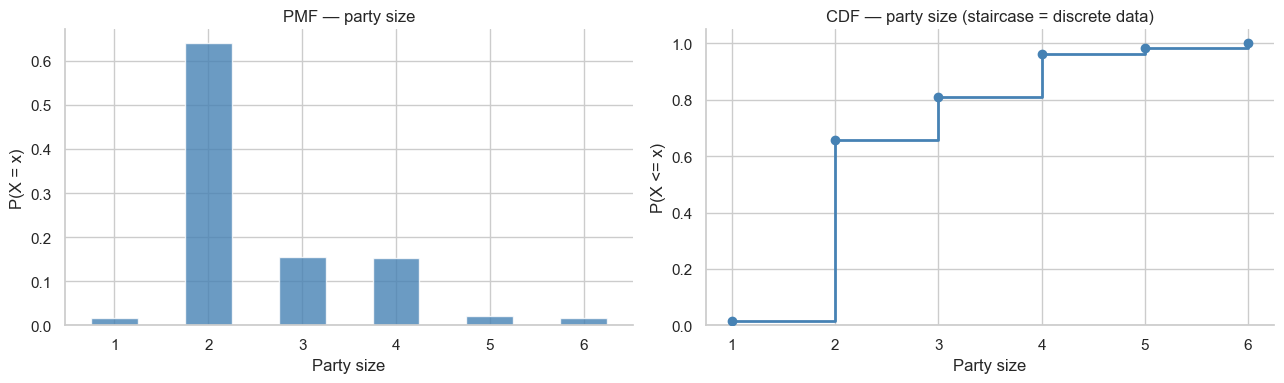

The CDF staircase jumps by exactly the PMF height at each value.
Between values it is flat — no probability mass lives there.


In [15]:
# Visualize PMF and CDF side by side to see the relationship clearly
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: PMF — probability at each exact value
axes[0].bar(pmf_party.index, pmf_party.values, color='steelblue', alpha=0.8, width=0.5)
axes[0].set_title('PMF — party size')
axes[0].set_xlabel('Party size')
axes[0].set_ylabel('P(X = x)')

# Right: CDF — cumulative probability up to each value
# Staircase shape is characteristic of discrete data
axes[1].step(cdf_party.index, cdf_party.values, where='post', color='steelblue', linewidth=2)
axes[1].scatter(cdf_party.index, cdf_party.values, color='steelblue', zorder=5)
axes[1].set_title('CDF — party size (staircase = discrete data)')
axes[1].set_xlabel('Party size')
axes[1].set_ylabel('P(X <= x)')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('cdf_vs_pmf.png', dpi=150, bbox_inches='tight')
plt.show()

print("The CDF staircase jumps by exactly the PMF height at each value.")
print("Between values it is flat — no probability mass lives there.")

---
## 2. CDF operations — answering real analytical questions
This is where CDF earns its place in production work.
The questions it answers naturally are the ones stakeholders actually ask.

In [16]:
def cdf_prob_at_most(cdf: pd.Series, x: float) -> float:
    """P(X <= x) — core CDF definition"""
    return cdf[cdf.index <= x].iloc[-1] if any(cdf.index <= x) else 0.0

def cdf_prob_less_than(cdf: pd.Series, x: float) -> float:
    """P(X < x)"""
    return cdf[cdf.index < x].iloc[-1] if any(cdf.index < x) else 0.0

def cdf_prob_between(cdf: pd.Series, low: float, high: float) -> float:
    """P(low <= X <= high)"""
    return cdf_prob_at_most(cdf, high) - cdf_prob_less_than(cdf, low)

def cdf_prob_greater_than(cdf: pd.Series, x: float) -> float:
    """P(X > x) = 1 - P(X <= x)"""
    return 1.0 - cdf_prob_at_most(cdf, x)

def cdf_percentile(cdf: pd.Series, p: float) -> float:
    """
    Return the value at the p-th percentile.
    p should be between 0 and 1.
    Returns the smallest x such that CDF(x) >= p.
    """
    assert 0 <= p <= 1, "p must be between 0 and 1"
    return cdf[cdf >= p].index[0]

print("--- CDF analytics on restaurant party size ---")
print(f"P(party size <= 2):          {cdf_prob_at_most(cdf_party, 2):.4f}")
print(f"P(party size < 2):           {cdf_prob_less_than(cdf_party, 2):.4f}")
print(f"P(2 <= party size <= 4):     {cdf_prob_between(cdf_party, 2, 4):.4f}")
print(f"P(party size > 4):           {cdf_prob_greater_than(cdf_party, 4):.4f}")
print(f"\n--- Percentiles ---")
print(f"25th percentile (Q1):        {cdf_percentile(cdf_party, 0.25)} people")
print(f"50th percentile (median):    {cdf_percentile(cdf_party, 0.50)} people")
print(f"75th percentile (Q3):        {cdf_percentile(cdf_party, 0.75)} people")
print(f"90th percentile:             {cdf_percentile(cdf_party, 0.90)} people")

--- CDF analytics on restaurant party size ---
P(party size <= 2):          0.6557
P(party size < 2):           0.0164
P(2 <= party size <= 4):     0.9467
P(party size > 4):           0.0369

--- Percentiles ---
25th percentile (Q1):        2 people
50th percentile (median):    2 people
75th percentile (Q3):        3 people
90th percentile:             4 people


---
## 3. CDF with continuous data — California Housing
**Source:** California Housing Survey, 1990 (Pace & Barry, 1997) — 20,640 census blocks  

With continuous data the CDF becomes a smooth curve instead of a staircase.
We use `scipy.stats.ecdf` — the production tool for empirical CDFs on continuous data.

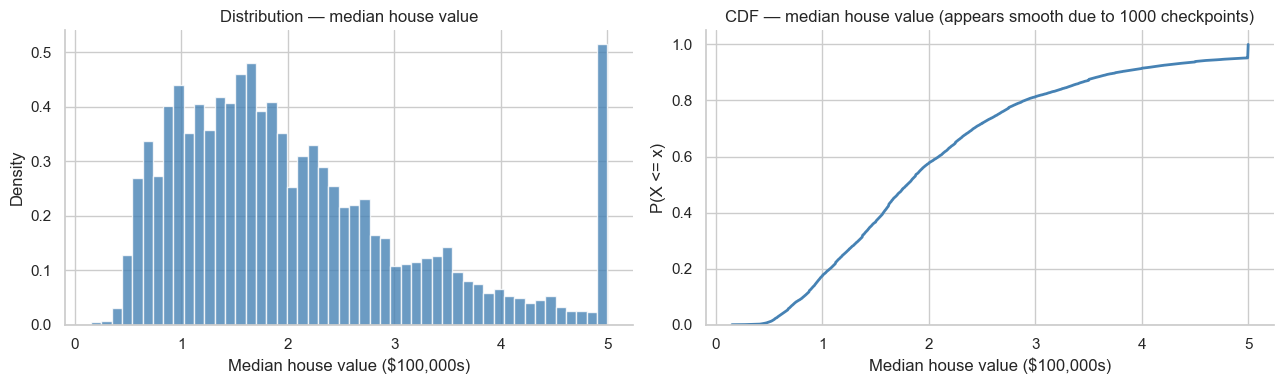

The S-curve shape is characteristic of continuous CDFs.
Steeper sections = more data concentrated there.
Flat sections = sparse data in that range.


In [17]:
housing = fetch_california_housing(as_frame=True) # `as_frame = True` tells scikit-learn to store everything inside the Bunch as pandas object instead of numpy arrays.
df = housing.frame # This returns an actual df.

# Median house value — continuous variable
house_value = df['MedHouseVal'].values

# scipy.stats.ecdf — production-grade empirical CDF for continuous data
ecdf = stats.ecdf(house_value)

# Generate x values for smooth plotting
x = np.linspace(house_value.min(), house_value.max(), 1000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram to show the shape of the distribution
axes[0].hist(house_value, bins=50, color='steelblue', alpha=0.8, density=True)
axes[0].set_title('Distribution — median house value')
axes[0].set_xlabel('Median house value ($100,000s)')
axes[0].set_ylabel('Density')

# Right: smooth CDF — S-curve characteristic of continuous data
axes[1].plot(x, ecdf.cdf.evaluate(x), color='steelblue', linewidth=2)
axes[1].set_title('CDF — median house value (appears smooth due to 1000 checkpoints)')
axes[1].set_xlabel('Median house value ($100,000s)')
axes[1].set_ylabel('P(X <= x)')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('cdf_continuous.png', dpi=150, bbox_inches='tight')
plt.show()

print("The S-curve shape is characteristic of continuous CDFs.")
print("Steeper sections = more data concentrated there.")
print("Flat sections = sparse data in that range.")

---
## 4. Percentiles on continuous data
Percentiles are one of the most practically useful things a CDF gives you directly.

--- Percentiles — median house value ($100,000s) ---
   10th percentile: $0.823 ($82,300)
   25th percentile: $1.196 ($119,600)
   50th percentile: $1.797 ($179,700)
   75th percentile: $2.647 ($264,725)
   90th percentile: $3.766 ($376,600)
   95th percentile: $4.898 ($489,810)
   99th percentile: $5.000 ($500,001)


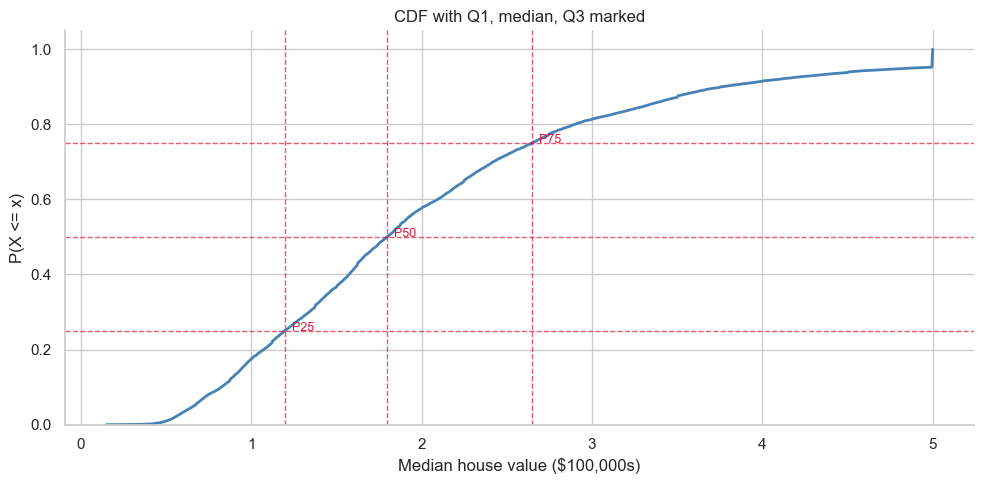

In [20]:
percentiles = [10, 25, 50, 75, 90, 95, 99]
values = np.percentile(house_value, percentiles)

print("--- Percentiles — median house value ($100,000s) ---")
for p, v in zip(percentiles, values):
    print(f"  {p:>3}th percentile: ${v:.3f} (${v*100_000:,.0f})")

# Visualize percentiles on the CDF
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, ecdf.cdf.evaluate(x), color='steelblue', linewidth=2)

# Mark key percentiles
for p, v in zip([25, 50, 75], np.percentile(house_value, [25, 50, 75])):
    ax.axvline(x=v, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y=p/100, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
    ax.annotate(f'  P{p}', xy=(v, p/100), fontsize=9, color='crimson')

ax.set_title('CDF with Q1, median, Q3 marked')
ax.set_xlabel('Median house value ($100,000s)')
ax.set_ylabel('P(X <= x)')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('cdf_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Comparing two CDFs — high vs low income neighborhoods
**Same split as PMF notebook:** high income (MedInc >= 5.0) vs low income (MedInc < 3.0)  

CDF comparison is cleaner than PMF comparison for continuous data —
no need to align indexes or worry about bin width. The curves speak for themselves.

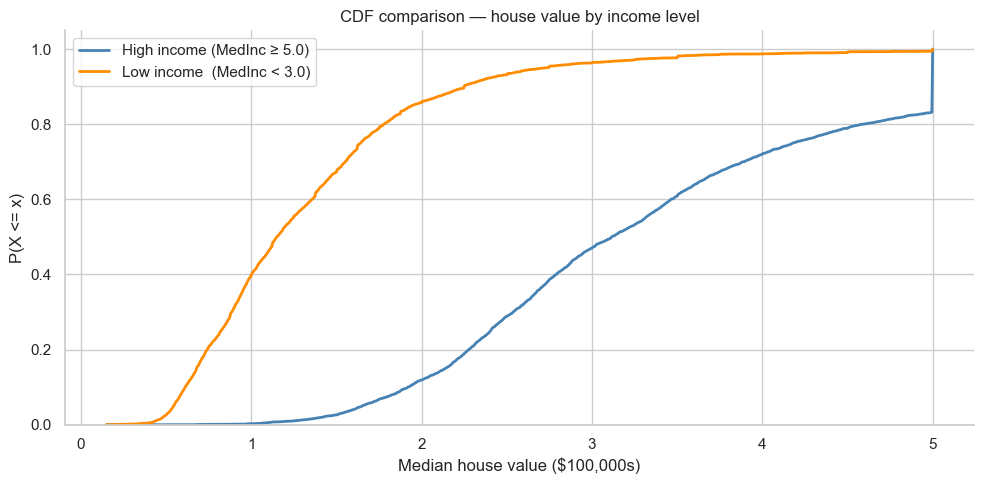

--- CDF comparison analytics ---
Median house value — high income: $3.116 ($312)
Median house value — low income:  $1.150 ($115)

How to read the comparison:
If the orange curve is to the LEFT of the blue curve,
low income neighborhoods have lower house values — the CDF reaches
the same cumulative probability at a smaller value.


In [19]:
high_income_val = df[df['MedInc'] >= 5.0]['MedHouseVal'].values
low_income_val  = df[df['MedInc'] <  3.0]['MedHouseVal'].values

ecdf_high = stats.ecdf(high_income_val)
ecdf_low  = stats.ecdf(low_income_val)

x_range = np.linspace(df['MedHouseVal'].min(), df['MedHouseVal'].max(), 1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_range, ecdf_high.cdf.evaluate(x_range), color='steelblue',  linewidth=2, label='High income (MedInc ≥ 5.0)')
ax.plot(x_range, ecdf_low.cdf.evaluate(x_range),  color='darkorange', linewidth=2, label='Low income  (MedInc < 3.0)')
ax.set_title('CDF comparison — house value by income level')
ax.set_xlabel('Median house value ($100,000s)')
ax.set_ylabel('P(X <= x)')
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig('cdf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("--- CDF comparison analytics ---")
print(f"Median house value — high income: ${np.median(high_income_val):.3f} (${np.median(high_income_val)*100:,.0f})")
print(f"Median house value — low income:  ${np.median(low_income_val):.3f} (${np.median(low_income_val)*100:,.0f})")
print(f"\nHow to read the comparison:")
print("If the orange curve is to the LEFT of the blue curve,")
print("low income neighborhoods have lower house values — the CDF reaches")
print("the same cumulative probability at a smaller value.")

---
## 6. CDF utility functions — reusable in production

In [ ]:
def cdf_summary(data: np.ndarray, label: str = 'variable') -> pd.DataFrame:
    """
    Generate a percentile summary table from raw data.
    Production-safe: uses only numpy.
    """
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    values = np.percentile(data, percentiles)
    return pd.DataFrame({
        'percentile': [f'P{p}' for p in percentiles],
        label: values.round(4)
    })

def cdf_rank(data: np.ndarray, x: float) -> float:
    """
    Return the percentile rank of a specific value.
    Answers: 'This value is higher than what percentage of the data?'
    """
    return (data <= x).mean()

def plot_cdf(data: np.ndarray, title: str = 'CDF', ax=None, **kwargs):
    """
    Reusable production-safe CDF plotter using scipy.stats.ecdf.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    ecdf = stats.ecdf(data)
    x = np.linspace(data.min(), data.max(), 1000)
    ax.plot(x, ecdf.cdf.evaluate(x), **kwargs)
    ax.set_title(title)
    ax.set_ylabel('P(X <= x)')
    ax.set_ylim(0, 1.05)
    return ax

# Demonstrate on California Housing
print("--- Percentile summary — median house value ---")
print(cdf_summary(house_value, 'MedHouseVal ($100Ks)').to_string(index=False))

print("\n--- Percentile rank examples ---")
print(f"A house valued at $200,000 is higher than {cdf_rank(house_value, 2.0):.1%} of all blocks")
print(f"A house valued at $300,000 is higher than {cdf_rank(house_value, 3.0):.1%} of all blocks")
print(f"A house valued at $500,000 is higher than {cdf_rank(house_value, 5.0):.1%} of all blocks")

---
## Summary

| Concept | What it means | How to compute |
|---|---|---|
| CDF | P(X <= x) for each x | `pmf.cumsum()` for discrete, `scipy.stats.ecdf` for continuous |
| Percentile | Value at which CDF reaches p% | `np.percentile(data, p)` |
| Percentile rank | What % of data falls below x | `(data <= x).mean()` |
| CDF comparison | Which distribution is stochastically larger | Plot both CDFs — left curve = smaller values |

**Discrete vs continuous CDFs:**

| Data type | CDF shape | Tool |
|---|---|---|
| Discrete | Staircase | `compute_pmf().cumsum()` |
| Continuous | Smooth S-curve | `scipy.stats.ecdf` |

**Production libraries used:**
- `pandas` — discrete CDF via cumsum
- `numpy` — percentiles and percentile ranks
- `scipy.stats.ecdf` — empirical CDF for continuous data
- `matplotlib` / `seaborn` — visualize

**Next:** Chapter 5 — Modeling Distributions (fitting theoretical distributions to real data)